# Teaching a 3D Printer with Reinforcement Learning
### A beginner-friendly Q-Learning demonstration

**What you will learn in this notebook:**
- What Reinforcement Learning (RL) actually is
- How to represent a 3D printing problem  for an agent
- How a Q-table learns by trial and error
- How to visualise the agent getting smarter over time
- How this simulation maps onto a real Prusa MK4 printer

**What you need to run this:**
- Python 3 with `numpy` and `matplotlib` (both are standard)
- No printer, no hardware


## Part 1 — What is Reinforcement Learning?

Reinforcement Learning (RL) is a machine learning paradigm where an AI "agent" learns to make decisions through trial and error in a dynamic environment. It operates on a reward-and-penalty system, aiming to take actions that maximize cumulative rewards over time.


### The 4 components of every RL problem

| Components | meaning | In our printer demo |
|---|---|---|
| **State** | What the agent can *see* right now | Interface temperature + current speed |
| **Action** | What the agent can *do* | Go faster / Stay / Go slower |
| **Reward** | How good was that action? | +1 if temp is in the bonding window |
| **Policy** | The learned strategy | "When hot → slow down; when cold → speed up" |

---

### Why is this *real* RL and not just a lookup table?

Key insight :

> When you print faster now, the part **accumulates heat**.
> That heat affects the temperature **several layers later**.
> So an action you take today has **delayed consequences**.

This is called **temporal credit assignment** — figuring out which past action caused a good or bad result later. This is the exact problem Q-learning was invented to solve.


## Part 2 — Setting Up

Run this cell first. It imports the two libraries we need.
- `numpy` → math with arrays
- `matplotlib` → plotting graphs


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set a random seed so results are reproducible every time you run
rng = np.random.default_rng(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Part 3 — The Fake Printer (Simulator)

We cannot risk crashing the real printer while the agent is still learning.
So we build a **mathematical fake** of the printer first.


### The physics we are modelling (simplified)

When plastic exits the nozzle at ~200°C and sits in air, it cools down.
How fast it cools depends on **how fast the print head is moving**:
- **Fast speed** → less time in the air → arrives at the next layer **hotter**
- **Slow speed** → more time in the air → arrives at the next layer **cooler**

There is also a **bulk heat effect**: if you print fast for many layers in a row,
the whole part warms up, and future layers start hotter than earlier ones.
This is why you cannot just pick one speed and forget it — the part's history matters.

### The bonding window

PLA plastic bonds well to the previous layer only if the interface is between **60°C and 90°C**.
- Below 60°C → layers do not stick (too cold, no adhesion)
- Above 90°C → layers sag and deform (too soft)

**The agent's job: keep the temperature inside that 60–90°C window, every single layer.**

Below we define all the physical constants.


In [2]:
# ── Physical constants ──────────────────────────────────────────────────
T_AMB      = 25.0   # Room temperature (°C)
T_EXTRUDE  = 200.0  # Temperature when plastic leaves the nozzle (°C) — typical PLA

BAND_LO    = 60.0   # Bottom of the bonding window (°C) — near Tg of PLA
BAND_HI    = 90.0   # Top of the bonding window (°C)

# The 5 speed levels the agent can choose from (mm/s)
# These correspond to real M220 feedrate commands on the printer
SPEEDS     = np.array([20., 35., 50., 65., 80.])

PATH_LEN   = 80.0   # Length of one layer (mm) — constant for a simple tower
KC         = 0.35   # How fast the layer cools in air (a "cooling constant")
N_LAYERS   = 60    # How many layers our test tower has

print("Physical constants defined.")
print(f"Bonding window: {BAND_LO}°C  →  {BAND_HI}°C")
print(f"Available speeds: {SPEEDS} mm/s")


Physical constants defined.
Bonding window: 60.0°C  →  90.0°C
Available speeds: [20. 35. 50. 65. 80.] mm/s


## Part 4 — Building the Fake Printer as a Python Class

In Python, we organise the simulator as a **class** called `FdmTowerEnv`.
Think of it as a self-contained box with:
- `reset()` → start a fresh print from scratch
- `_observe()` → read the current interface temperature (this is what the thermal camera would do on the real printer)
- `step(action)` → apply one action and get back (new temperature, reward, is print done?)

This structure is intentional: on the real printer, we just replace `_observe()`
with a line that reads from our thermal camera, and `step()` with a line that
sends `M220` to OctoPrint. The agent never changes.


In [3]:
class FdmTowerEnv:
    """
    A simplified simulation of printing a thin-walled constant-section tower.

    The agent picks a speed at each layer.
    The environment returns the new interface temperature and a reward.
    """

    def reset(self):
        self.layer  = 0      # we are at layer zero, print hasn't started
        self.bulk   = 0.0    # the part is cold, no heat built up yet
        self.spd_i  = 2      # start at speed index 2 = 50 mm/s (the middle speed)
        return self._observe()

    def _observe(self):
        v       = SPEEDS[self.spd_i]           # what speed are we going?
        t_layer = PATH_LEN / v                 # how many seconds does one layer take?
        env     = T_AMB + self.bulk            # how warm is the air around the part?
        O = env + (T_EXTRUDE - env) * np.exp(-KC * t_layer)             # Newton's Law of Cooling
        return O

    def step(self, action):
        """
        Apply an action (0=decrease speed, 1=hold, 2=increase speed).
        Returns: (new_temperature, reward, is_print_finished)

        On the REAL printer, the action would be:
            octoprint.send_command(f'M220 S{new_speed_percent}')
        """
        # ── Apply action: shift speed index by -1, 0, or +1 ──
        self.spd_i = int(np.clip(self.spd_i + (action - 1), 0, len(SPEEDS) - 1))

        # ── Update the bulk heat (heat accumulates with fast printing) ──
        v = SPEEDS[self.spd_i]
        self.bulk = np.clip(
            self.bulk + 3.0 * (v / SPEEDS[-1]) - 0.20 * self.bulk,
            0.0, 60.0
        )

        self.layer += 1
        O    = self._observe()        # read the new temperature
        done = self.layer >= N_LAYERS # is this the last layer?

        # ── Calculate reward ──────────────────────────────────────────────
        if BAND_LO <= O <= BAND_HI:       # temperature between 60 and 90°C?
            reward = 1.0                   # ✅ perfect, full point
        elif O < BAND_LO:                  # too cold?
            reward = -0.05 * (BAND_LO - O) # small penalty, bigger the further below
        else:                              # too hot?
            reward = -0.05 * (O - BAND_HI) # small penalty, bigger the further above

        return O, reward, done

print(" FdmTowerEnv class defined.")


 FdmTowerEnv class defined.


## Part 5 — Explore the Simulator by Hand

Before we let the agent learn, let's manually run a few steps so we can *feel* what the environment does.

We will start a print, keep the speed constant, and watch what happens to temperature.


In [4]:
# ── Manual exploration ───────────────────────────────────────────────────
env  = FdmTowerEnv()
temp = env.reset()

print("=== Manual print run (always holding speed, action=1) ===")
print(f"{'Layer':>6}  {'Temp (°C)':>10}  {'Speed (mm/s)':>13}  {'In window?':>10}")
print("-" * 50)

temps_manual = [temp]
for layer in range(1, N_LAYERS + 1):
    temp, reward, done = env.step(1)   # action=1 means HOLD current speed
    in_band = "✅ YES" if BAND_LO <= temp <= BAND_HI else "❌ NO"
    if layer <= 45 or layer == N_LAYERS:   # print first 45 layers + last
        print(f"{layer:>6}  {temp:>10.1f}  {SPEEDS[env.spd_i]:>13.0f}  {in_band:>10}")
    if layer == 45:
        print("   ...  (skipping middle layers) ...")
    if done:
        break

print()
print("Notice: temperature climbs because the part accumulates heat.")
print("A fixed speed cannot hold the bonding window as the print progresses.")


=== Manual print run (always holding speed, action=1) ===
 Layer   Temp (°C)   Speed (mm/s)  In window?
--------------------------------------------------
     1       125.8             50        ❌ NO
     2       126.4             50        ❌ NO
     3       126.9             50        ❌ NO
     4       127.3             50        ❌ NO
     5       127.7             50        ❌ NO
     6       127.9             50        ❌ NO
     7       128.1             50        ❌ NO
     8       128.3             50        ❌ NO
     9       128.4             50        ❌ NO
    10       128.5             50        ❌ NO
    11       128.6             50        ❌ NO
    12       128.7             50        ❌ NO
    13       128.8             50        ❌ NO
    14       128.8             50        ❌ NO
    15       128.8             50        ❌ NO
    16       128.9             50        ❌ NO
    17       128.9             50        ❌ NO
    18       128.9             50        ❌ NO
    19       128.

## Part 5B — 3D Visualization of the Simulated Printed Tower

The simulator does not create real geometry, but it prints layer by layer.

Here we draw a simplified 3D tower:
- Each layer is a thin block
- The color shows the simulated interface temperature
- Green temperature range means the bonding window

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def run_fixed_speed_print():
    """
    Run one simulated print using a fixed-speed policy.
    Action 1 means 'hold current speed'.
    """
    env = FdmTowerEnv()
    O = env.reset()

    temps = [O]
    speeds = [SPEEDS[env.spd_i]]

    done = False
    while not done:
        O, reward, done = env.step(1)   # 1 = hold speed
        temps.append(O)
        speeds.append(SPEEDS[env.spd_i])

    return np.array(temps), np.array(speeds)

baseline_temps, baseline_speeds = run_fixed_speed_print()

print("Number of simulated layers:", len(baseline_temps))
print("Temperature range:", baseline_temps.min(), "to", baseline_temps.max())

Number of simulated layers: 61
Temperature range: 124.9615861735426 to 128.9814950394581


/tmp/ipykernel_1975/202625668.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")


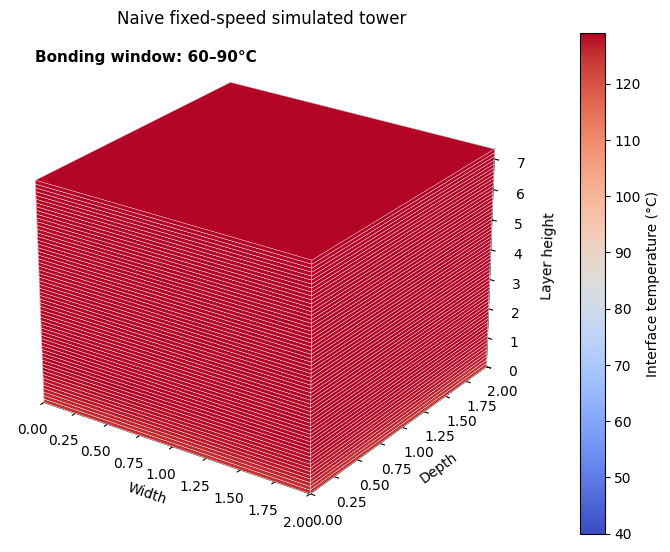

In [6]:
def add_box(ax, x0, x1, y0, y1, z0, z1, color):
    """
    Add one rectangular layer/block to a 3D plot.
    """
    vertices = [
        [(x0, y0, z0), (x1, y0, z0), (x1, y1, z0), (x0, y1, z0)],  # bottom
        [(x0, y0, z1), (x1, y0, z1), (x1, y1, z1), (x0, y1, z1)],  # top
        [(x0, y0, z0), (x1, y0, z0), (x1, y0, z1), (x0, y0, z1)],  # front
        [(x0, y1, z0), (x1, y1, z0), (x1, y1, z1), (x0, y1, z1)],  # back
        [(x0, y0, z0), (x0, y1, z0), (x0, y1, z1), (x0, y0, z1)],  # left
        [(x1, y0, z0), (x1, y1, z0), (x1, y1, z1), (x1, y0, z1)]   # right
    ]

    box = Poly3DCollection(
        vertices,
        facecolors=color,
        edgecolors="white",
        linewidths=0.25,
        alpha=0.95
    )
    ax.add_collection3d(box)


def plot_3d_temperature_tower(temps, title="3D simulated printed tower"):
    """
    Draw a simplified 3D printed tower.
    Each layer is colored by simulated interface temperature.
    """
    temps = np.asarray(temps)

    fig = plt.figure(figsize=(7, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Geometry of the fake tower
    width = 2.0
    depth = 2.0
    layer_height = 0.12

    # Color scale centered around the bonding-window region
    norm = mcolors.Normalize(
        vmin=min(temps.min(), BAND_LO - 20),
        vmax=max(temps.max(), BAND_HI + 30)
    )
    cmap = cm.get_cmap("coolwarm")

    for i, temp in enumerate(temps):
        z0 = i * layer_height
        z1 = (i + 1) * layer_height
        color = cmap(norm(temp))

        add_box(
            ax,
            x0=0, x1=width,
            y0=0, y1=depth,
            z0=z0, z1=z1,
            color=color
        )

    # Axes limits
    ax.set_xlim(0, width)
    ax.set_ylim(0, depth)
    ax.set_zlim(0, len(temps) * layer_height)

    ax.set_xlabel("Width")
    ax.set_ylabel("Depth")
    ax.set_zlabel("Layer height")
    ax.set_title(title)

    # Better viewing angle
    ax.view_init(elev=25, azim=-55)

    # Colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.1)
    cbar.set_label("Interface temperature (°C)")

    # Add bonding-window text
    ax.text2D(
        0.05, 0.94,
        f"Bonding window: {BAND_LO:.0f}–{BAND_HI:.0f}°C",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


plot_3d_temperature_tower(
    baseline_temps,
    title="Naive fixed-speed simulated tower"
)

## Part 6 — State Discretisation (Making the World Manageable)

The agent needs to store what it has learned in a table called the **Q-table**.
But a continuous temperature like 73.4°C would mean infinitely many table rows.

So we **bin** the temperature into 5 broad categories:

| Bin | Meaning | Temperature range |
|---|---|---|
| 0 | Far too cold | Below 40°C |
| 1 | A bit cold | 40–60°C |
| 2 | ✅ In the bonding window | 60–90°C |
| 3 | A bit hot | 90–110°C |
| 4 | Far too hot | Above 110°C |

We also include the current speed index (0–4) in the state, because the same temperature
means something different if you are already printing fast vs. printing slow.

**Total states = 5 temperature bins × 5 speed levels = 25 states** — small enough to fit in one table.


In [7]:
def discretise(temp, speed_index):
    """
    Convert a continuous temperature + speed index into a single integer state.

    This collapses the infinite space of possible temperatures into just 5 buckets,
    and combines it with the current speed (0-4) to get a single state number (0-24).
    """
    if   temp < BAND_LO - 20:  temp_bin = 0   # far cold  (< 40°C)
    elif temp < BAND_LO:       temp_bin = 1   # cold      (40–60°C)
    elif temp <= BAND_HI:      temp_bin = 2   # ✅ in band (60–90°C)
    elif temp <= BAND_HI + 20: temp_bin = 3   # hot       (90–110°C)
    else:                      temp_bin = 4   # far hot   (> 110°C)

    # Combine: each of the 5 temp bins has 5 speed sub-states → 25 total
    return temp_bin * len(SPEEDS) + speed_index

N_STATES  = 5 * len(SPEEDS)   # 25 total states
N_ACTIONS = 3                  # decrease / hold / increase

# ── Quick demo ──
print("State discretisation examples:")
print(f"  Temp=45°C, speed_idx=2  →  state #{discretise(45, 2)}  (cold + mid speed)")
print(f"  Temp=72°C, speed_idx=2  →  state #{discretise(72, 2)}  (in band + mid speed)")
print(f"  Temp=105°C, speed_idx=4 →  state #{discretise(105,4)}  (hot + fast speed)")
print()
print(f"Total number of states:  {N_STATES}")
print(f"Total number of actions: {N_ACTIONS}  (0=slow down, 1=hold, 2=speed up)")


State discretisation examples:
  Temp=45°C, speed_idx=2  →  state #7  (cold + mid speed)
  Temp=72°C, speed_idx=2  →  state #12  (in band + mid speed)
  Temp=105°C, speed_idx=4 →  state #19  (hot + fast speed)

Total number of states:  25
Total number of actions: 3  (0=slow down, 1=hold, 2=speed up)


## Part 7 — The Q-Table (The Agent's Memory)

The Q-table is just a 2D array: **rows = states, columns = actions**.

Each cell holds a number called a **Q-value**, which represents:
> *"If I am in this state and I take this action, how much total future reward do I expect?"*

| | Action 0 (slow down) | Action 1 (hold) | Action 2 (speed up) |
|---|---|---|---|
| State 0 (far cold, slow) | ? | ? | ? |
| State 1 (cold, slow) | ? | ? | ? |
| ... | ... | ... | ... |
| State 24 (far hot, fast) | ? | ? | ? |

At the start, all Q-values are 0 — the agent knows nothing.

After each action, it updates the Q-value using the **Bellman equation**:

```
Q(state, action) ← Q(state, action) + α × [reward + γ × max(Q(next_state)) − Q(state, action)]
```

Explanation:
- `α` (alpha) = **learning rate** — how fast to update (0.2 = update 20% toward new info)
- `γ` (gamma) = **discount factor** — how much to care about future rewards (0.95 = care a lot)
- `reward + γ × max(Q(next_state))` = what we *expected* to get vs. what we *actually* got


In [8]:
# A fresh Q-table — the agent knows absolutely nothing yet
Q = np.zeros((N_STATES, N_ACTIONS))

print("=== Fresh Q-table: the agent knows nothing ===")
print(f"Shape: {Q.shape}  →  {N_STATES} states  x  {N_ACTIONS} actions")
print()
print(f"{'State':>6}  {'What this state means':>26}  {'Slow down':>10}  {'Hold':>8}  {'Speed up':>9}")
print("-" * 70)

bin_names = ["far cold", "cold    ", "IN BAND ", "hot     ", "far hot "]
for tb in range(5):
    for si in range(5):
        state = tb * 5 + si
        label = f"{bin_names[tb]} / {int(SPEEDS[si])} mm/s"
        print(f"{state:>6}  {label:>26}  {Q[state,0]:>10.3f}  {Q[state,1]:>8.3f}  {Q[state,2]:>9.3f}")

print()
print("Every cell is 0.000 — the agent has no preference yet.")
print("When all three actions tie, it picks randomly (that is exploration).")

=== Fresh Q-table: the agent knows nothing ===
Shape: (25, 3)  →  25 states  x  3 actions

 State       What this state means   Slow down      Hold   Speed up
----------------------------------------------------------------------
     0          far cold / 20 mm/s       0.000     0.000      0.000
     1          far cold / 35 mm/s       0.000     0.000      0.000
     2          far cold / 50 mm/s       0.000     0.000      0.000
     3          far cold / 65 mm/s       0.000     0.000      0.000
     4          far cold / 80 mm/s       0.000     0.000      0.000
     5          cold     / 20 mm/s       0.000     0.000      0.000
     6          cold     / 35 mm/s       0.000     0.000      0.000
     7          cold     / 50 mm/s       0.000     0.000      0.000
     8          cold     / 65 mm/s       0.000     0.000      0.000
     9          cold     / 80 mm/s       0.000     0.000      0.000
    10          IN BAND  / 20 mm/s       0.000     0.000      0.000
    11          IN BAN

## Part 8 — Training the Agent

The agent runs 400 fake print jobs (episodes).

In each episode:
1. Start a fresh print
2. At every layer, either **explore** (try something random) or **exploit** (use the best known action)
3. Update the Q-table after each layer
4. Repeat

The balance between exploration and exploitation is controlled by **ε (epsilon)**:
- Early episodes: ε is high → mostly random exploration ("try everything")
- Later episodes: ε shrinks → mostly use what was learned

This is called an **ε-greedy** strategy.


In [9]:
# ── Step 1: Set the three knobs ───────────────────────
learning_rate   = 0.2    # alpha:  how much to trust each new experience
discount_factor = 0.95   # gamma:  how much future rewards matter
number_of_prints = 400   # how many complete fake print jobs to run

# ── Step 2: Create a blank Q-table (agent knows nothing) ─
q_table = np.zeros((N_STATES, N_ACTIONS))
# q_table shape: 25 rows (states) x 3 columns (actions)
# every value starts at 0.0 — no preference yet

# ── Step 3: Create a list to track score per print ───
scores_per_print = []

# ── Step 4: Create the fake printer ──────────────────
printer = FdmTowerEnv()

# ── Step 5: Create the random number generator ───────
rng = np.random.default_rng(seed=42)

print("Setup done. Starting training...\n")

# ══════════════════════════════════════════════════════
#  OUTER LOOP — one full print job per episode
# ══════════════════════════════════════════════════════

for print_number in range(number_of_prints):

    # --- How much to explore this print? ---
    # Starts near 1.0 (mostly random), shrinks toward 0.05 (mostly learned)
    exploration_chance = max(0.05, 1.0 - print_number / (0.7 * number_of_prints))

    # --- Start a fresh print ---
    current_temp  = printer.reset()
    current_state = discretise(current_temp, printer.spd_i)
    score_this_print = 0.0

    # ══════════════════════════════════════════════════
    #  INNER LOOP — one layer at a time (60 layers)
    # ══════════════════════════════════════════════════

    for layer_number in range(N_LAYERS):

        # ── Decide: explore or exploit? ──────────────
        random_roll = rng.random()          # random number between 0.0 and 1.0

        if random_roll < exploration_chance:
            chosen_action = rng.integers(N_ACTIONS)   # random: 0, 1, or 2
        else:
            chosen_action = int(np.argmax(q_table[current_state]))
            # argmax picks the action with the highest Q-value in this row

        # ── Print the layer (apply the action) ───────
        new_temp, reward_earned, print_finished = printer.step(chosen_action)
        new_state = discretise(new_temp, printer.spd_i)

        # ── Bellman update —
        current_q_value  = q_table[current_state, chosen_action]
        best_future_q    = np.max(q_table[new_state])
        what_we_learned  = reward_earned + discount_factor * best_future_q
        error            = what_we_learned - current_q_value
        nudge            = learning_rate * error

        q_table[current_state, chosen_action] = current_q_value + nudge

        # ── Move to next layer ────────────────────────
        current_state     = new_state
        score_this_print += reward_earned

        if print_finished:
            break

    # ── Save the score for this print ────────────────
    scores_per_print.append(score_this_print)

    # ── Print progress every 50 prints ───────────────
    if (print_number + 1) % 50 == 0:
        recent_avg = np.mean(scores_per_print[-50:])
        print(f"Print {print_number+1:>4} / {number_of_prints} "
              f"| explore chance: {exploration_chance:.0%} "
              f"| avg score last 50 prints: {recent_avg:+.1f}")

print("\nTraining complete!")
print(f"  Score at the start  (avg first 20):  {np.mean(scores_per_print[:20]):+.1f}")
print(f"  Score at the end    (avg last 20):   {np.mean(scores_per_print[-20:]):+.1f}")

np.save("q_table.npy", q_table)
print("Q-table saved.")

Setup done. Starting training...

Print   50 / 400 | explore chance: 82% | avg score last 50 prints: -59.1
Print  100 / 400 | explore chance: 65% | avg score last 50 prints: -16.4
Print  150 / 400 | explore chance: 47% | avg score last 50 prints: +14.6
Print  200 / 400 | explore chance: 29% | avg score last 50 prints: +36.8
Print  250 / 400 | explore chance: 11% | avg score last 50 prints: +48.2
Print  300 / 400 | explore chance: 5% | avg score last 50 prints: +55.6
Print  350 / 400 | explore chance: 5% | avg score last 50 prints: +55.5
Print  400 / 400 | explore chance: 5% | avg score last 50 prints: +56.4

Training complete!
  Score at the start  (avg first 20):  -70.5
  Score at the end    (avg last 20):   +56.6
Q-table saved.


## Part 9 — Running a Test Print with the Learned Policy

Now we use the trained Q-table to print one tower (no exploration, fully greedy).
We also run a naive baseline: fixed mid-speed, no learning.


In [10]:
# ── Test print 1: use the learned Q-table ─────────────
print("Running test print with the LEARNED policy...")

test_printer  = FdmTowerEnv()
current_temp  = test_printer.reset()
current_state = discretise(current_temp, test_printer.spd_i)

learned_temps  = [current_temp]            # record starting temp
learned_speeds = [SPEEDS[test_printer.spd_i]]  # record starting speed

for layer_number in range(N_LAYERS):

    # Always pick the action with the highest Q-value — no random exploration
    best_action = int(np.argmax(q_table[current_state]))

    new_temp, reward_earned, print_finished = test_printer.step(best_action)
    current_state = discretise(new_temp, test_printer.spd_i)

    learned_temps.append(new_temp)
    learned_speeds.append(SPEEDS[test_printer.spd_i])

    if print_finished:
        break

learned_temps  = np.array(learned_temps)
learned_speeds = np.array(learned_speeds)

# ── Test print 2: naive baseline — always hold speed ──
print("Running test print with the NAIVE baseline (fixed speed)...")

naive_printer = FdmTowerEnv()
current_temp  = naive_printer.reset()

baseline_temps = [current_temp]            # record starting temp

for layer_number in range(N_LAYERS):

    # action=1 means hold speed — never changes, ignores temperature completely
    new_temp, reward_earned, print_finished = naive_printer.step(1)

    baseline_temps.append(new_temp)

    if print_finished:
        break

baseline_temps = np.array(baseline_temps)

# ── Compare results ────────────────────────────────────
# Check how many layers landed inside the bonding window (60–90°C)
# True/False array → np.mean counts the Trues and divides by total
learned_in_window  = (learned_temps  >= BAND_LO) & (learned_temps  <= BAND_HI)
baseline_in_window = (baseline_temps >= BAND_LO) & (baseline_temps <= BAND_HI)

frac_learned  = np.mean(learned_in_window)
frac_baseline = np.mean(baseline_in_window)

print(f"\nLayers inside bonding window (60–90°C):")
print(f"   Learned policy    : {frac_learned:.0%}")
print(f"   Naive fixed speed : {frac_baseline:.0%}")

Running test print with the LEARNED policy...
Running test print with the NAIVE baseline (fixed speed)...

Layers inside bonding window (60–90°C):
   Learned policy    : 97%
   Naive fixed speed : 0%


## Part 9B — Visual Comparison of Printed Towers

Now we compare two simulated towers:

1. A naive fixed-speed tower  
2. A tower controlled by the learned Q-policy

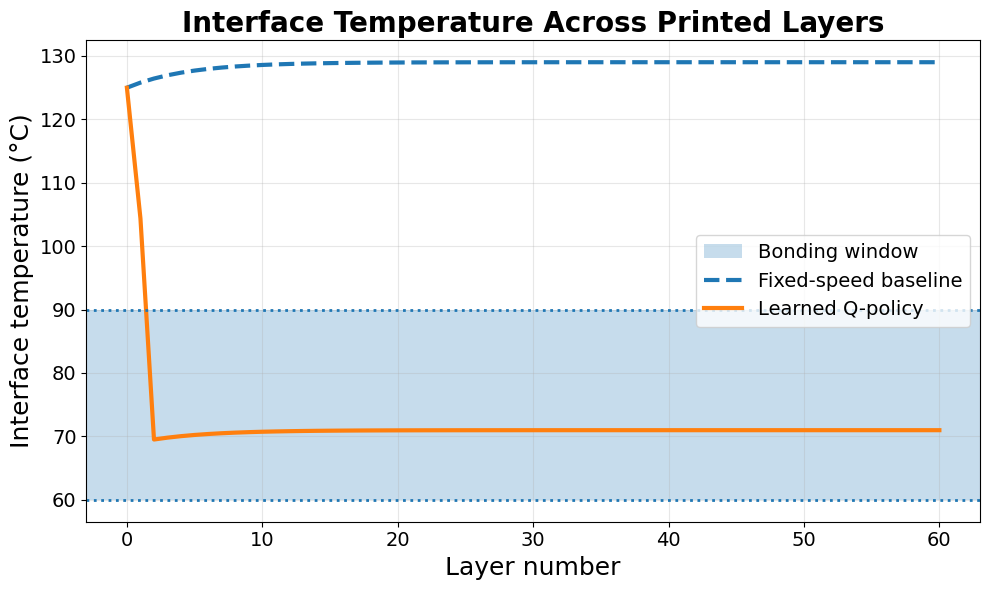

In [11]:
def plot_temperature_vs_layer(baseline_temps, learned_temps):
    layers_base = np.arange(len(baseline_temps))
    layers_learned = np.arange(len(learned_temps))

    plt.figure(figsize=(10, 6))

    # Bonding window
    plt.axhspan(BAND_LO, BAND_HI, alpha=0.25, label="Bonding window")

    # Temperature curves
    plt.plot(layers_base, baseline_temps, linestyle="--", linewidth=3,
             label="Fixed-speed baseline")
    plt.plot(layers_learned, learned_temps, linewidth=3,
             label="Learned Q-policy")

    # Bonding-window boundaries
    plt.axhline(BAND_LO, linestyle=":", linewidth=2)
    plt.axhline(BAND_HI, linestyle=":", linewidth=2)

    plt.xlabel("Layer number", fontsize=18)
    plt.ylabel("Interface temperature (°C)", fontsize=18)
    plt.title("Interface Temperature Across Printed Layers", fontsize=20, fontweight="bold")

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_temperature_vs_layer(baseline_temps, learned_temps)

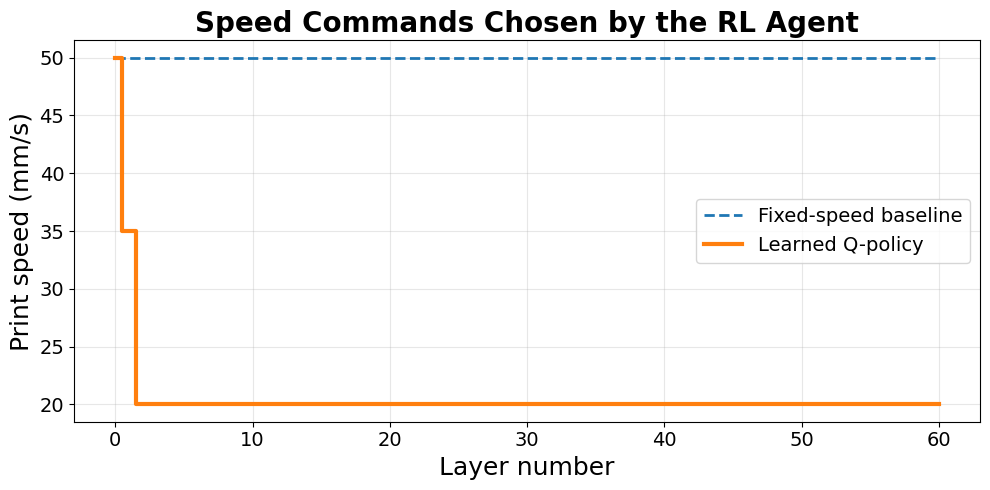

In [12]:
def plot_speed_vs_layer(learned_speeds, baseline_speeds=None):
    layers = np.arange(len(learned_speeds))

    plt.figure(figsize=(10, 5))

    if baseline_speeds is not None:
        plt.step(np.arange(len(baseline_speeds)), baseline_speeds,
                 where="mid", linestyle="--", linewidth=2,
                 label="Fixed-speed baseline")

    plt.step(layers, learned_speeds, where="mid", linewidth=3,
             label="Learned Q-policy")

    plt.xlabel("Layer number", fontsize=18)
    plt.ylabel("Print speed (mm/s)", fontsize=18)
    plt.title("Speed Commands Chosen by the RL Agent", fontsize=20, fontweight="bold")

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_speed_vs_layer(learned_speeds, baseline_speeds)

## Part 10 — Visualising the Results

Three panels:
- **(a)** The reward per episode — does it climb? That's the agent learning.
- **(b)** Interface temperature layer by layer — does the blue line stay in the green zone?
- **(c)** The speed commands the trained agent chose each layer.


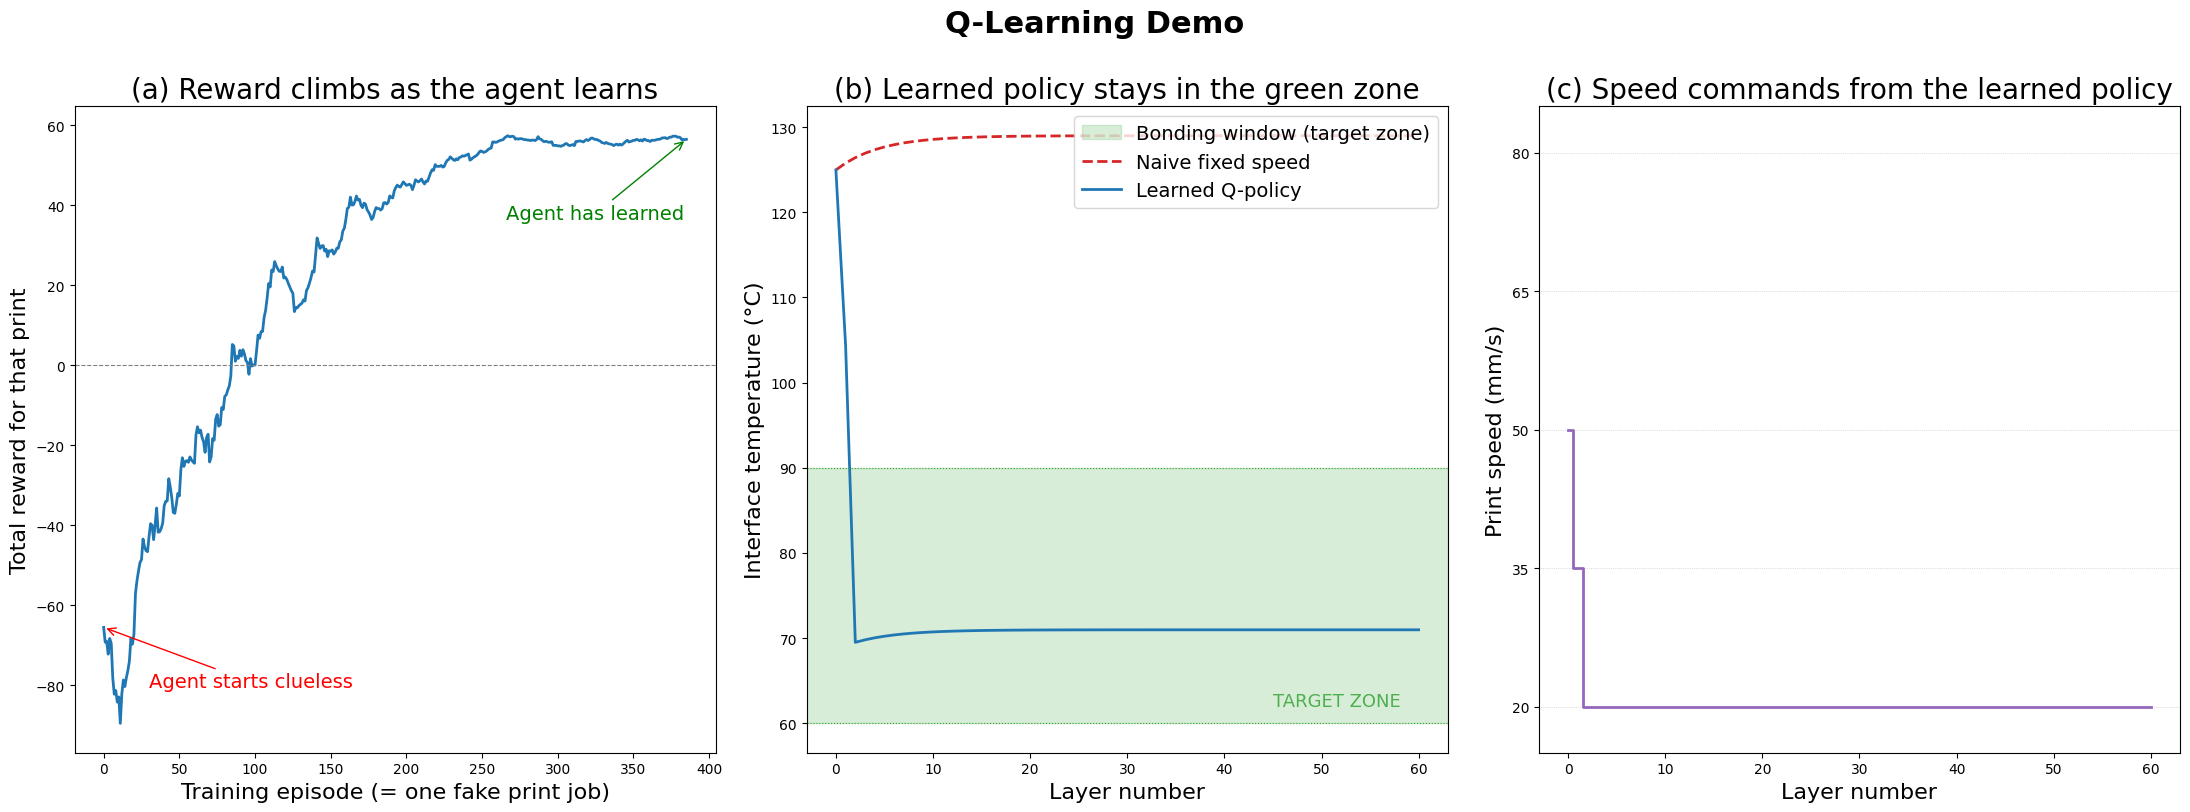

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle("Q-Learning Demo", fontsize=22, fontweight="bold", y=1.01)

# ── Panel (a): learning curve ──────────────────────────────────────────────────
smooth_window   = 15
smoothed_scores = np.convolve(
    scores_per_print, np.ones(smooth_window) / smooth_window, mode="valid"
)

axes[0].plot(smoothed_scores, color="#1f77b4", linewidth=2)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("(a) Reward climbs as the agent learns", fontsize=20)
axes[0].set_xlabel("Training episode (= one fake print job)", fontsize=16)
axes[0].set_ylabel("Total reward for that print", fontsize=16)
axes[0].annotate("Agent starts clueless",
                 xy=(0, smoothed_scores[0]),
                 xytext=(30, smoothed_scores[0] - 15),
                 fontsize=14, color="red",
                 arrowprops=dict(arrowstyle="->", color="red"))
axes[0].annotate("Agent has learned",
                 xy=(len(smoothed_scores) - 1, smoothed_scores[-1]),
                 xytext=(len(smoothed_scores) - 120, smoothed_scores[-1] - 20),
                 fontsize=14, color="green",
                 arrowprops=dict(arrowstyle="->", color="green"))

# ── Panel (b): temperature traces ─────────────────────────────────────────────
axes[1].axhspan(BAND_LO, BAND_HI, color="#2ca02c", alpha=0.18,
                label="Bonding window (target zone)")
axes[1].plot(baseline_temps, "--", color="#d62728", linewidth=2, label="Naive fixed speed")
axes[1].plot(learned_temps,  "-",  color="#1f77b4", linewidth=2, label="Learned Q-policy")
axes[1].axhline(BAND_LO, color="#2ca02c", linestyle=":", linewidth=0.8)
axes[1].axhline(BAND_HI, color="#2ca02c", linestyle=":", linewidth=0.8)
axes[1].set_title("(b) Learned policy stays in the green zone", fontsize=20)
axes[1].set_xlabel("Layer number", fontsize=16)
axes[1].set_ylabel("Interface temperature (°C)", fontsize=16)
axes[1].legend(loc="upper right", fontsize=14)
axes[1].text(45, BAND_LO + 2, "TARGET ZONE", color="#2ca02c", fontsize=13, alpha=0.8)

# ── Panel (c): speed commands ──────────────────────────────────────────────────
axes[2].step(range(len(learned_speeds)), learned_speeds, where="mid",
             color="#9467bd", linewidth=2)
axes[2].set_title("(c) Speed commands from the learned policy", fontsize=20)
axes[2].set_xlabel("Layer number", fontsize=16)
axes[2].set_ylabel("Print speed (mm/s)", fontsize=16)
axes[2].set_ylim(SPEEDS[0] - 5, SPEEDS[-1] + 5)
axes[2].set_yticks(SPEEDS)
for spd in SPEEDS:
    axes[2].axhline(spd, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

## Part 11 — Look Inside the Q-Table

The Q-table is what the agent actually learned. Let's visualise it directly.
Each row is a state, each column is an action. Brighter = the agent prefers that action in that state.


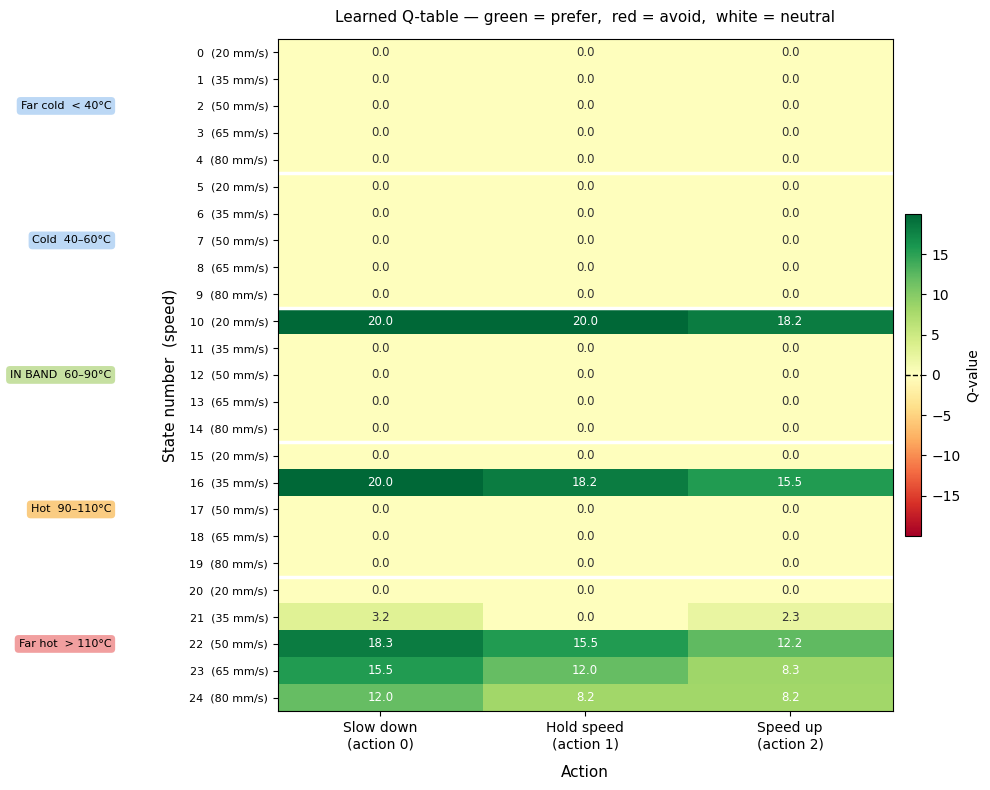

In [14]:
from matplotlib.colors import TwoSlopeNorm

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")

abs_max = np.abs(q_table).max()
norm    = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
im      = ax.imshow(q_table, aspect="auto", cmap="RdYlGn", norm=norm)

# Q-value numbers inside every cell
for row in range(N_STATES):
    for col in range(N_ACTIONS):
        val   = q_table[row, col]
        color = "white" if abs(val) > abs_max * 0.4 else "#333333"
        ax.text(col, row, f"{val:.1f}", ha="center", va="center",
                fontsize=8.5, color=color, fontweight="500")

# White dividers between temperature groups
for boundary in [4.5, 9.5, 14.5, 19.5]:
    ax.axhline(boundary, color="white", linewidth=2.5)

# X-axis
ax.set_xticks(range(N_ACTIONS))
ax.set_xticklabels(["Slow down\n(action 0)", "Hold speed\n(action 1)",
                    "Speed up\n(action 2)"], fontsize=10)
ax.set_xlabel("Action", fontsize=11, labelpad=10)

# Y-axis: state number + speed
y_labels = [f"{row}  ({int(SPEEDS[row % 5])} mm/s)" for row in range(N_STATES)]
ax.set_yticks(range(N_STATES))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_ylabel("State number  (speed)", fontsize=11, labelpad=8)

# Temperature bin labels — coloured boxes to the left of the y-axis
bin_labels = ["Far cold  < 40°C", "Cold  40–60°C", "IN BAND  60–90°C",
              "Hot  90–110°C",    "Far hot  > 110°C"]
bin_colors = ["#b5d4f4", "#b5d4f4", "#c0dd97", "#fac775", "#f09595"]
for tb in range(5):
    ax.annotate(bin_labels[tb],
                xy=(-0.5, tb * 5 + 2), xycoords="data",
                fontsize=8, va="center", ha="right",
                xytext=(-120, 0), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.35", facecolor=bin_colors[tb],
                          edgecolor="none", alpha=0.9))

ax.set_title("Learned Q-table — green = prefer,  red = avoid,  white = neutral",
             fontsize=11, pad=12)

# Colorbar — tight to the heatmap, no overlap
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Q-value", fontsize=10)
cbar.ax.axhline(0, color="black", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

## Summary

| Concept | What it means | Where you saw it |
|---|---|---|
| Agent | The decision-maker | The Q-table update loop |
| State | What the agent observes | Temperature bin × speed level |
| Action | What the agent can do | Decrease / Hold / Increase speed |
| Reward | Signal for good/bad | +1 in band, negative outside |
| Exploration | Trying random actions | ε-greedy, early episodes |
| Exploitation | Using learned knowledge | ε-greedy, late episodes |
